## Model Selection

Before we move on we would like to choose the best possible model for each of the two cases: daily forecast and hourly forecast. It seems that for the daily forecast in the long term you choose linear_order2 in the short to medium term potentially hybrid_order2. For the hourly forecast it seems that just using XGBoost is the best possible model.

The main question is that in the daily forecast if we were to optimise the hyperparameters of the XGBoost model within the hybrid model would it make hybrid_order2 better than linear_order2 in both the short and long term. It would also be nice to do hyperparamter optimisation for the hourly forecast as well just to see whether we can improve the predictions or not. 

Finally it would be good to look at SHAP values to see if we can drop any of the features, particualarly some of the lags as they can make the models computationally expensive.

For our own use (maybe delete later): http://kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning

https://hyperopt.github.io/hyperopt/?source=post_page

https://github.com/hyperopt/hyperopt/wiki/FMin

In [12]:
from hyperopt import hp, fmin, tpe, hp, Trials
from hyperopt.pyll import scope
import xgboost as xgb
import pandas as pd
from jfk_taxis import load_design, load_config, load_models, load_lags, run_forecasts, create_val_data, wrapped_objective, save_hyperparams, load_hyperparams, save_obj, load_obj, split_params, test_hyperparams
from sklearn.linear_model import LinearRegression
import numpy as np

In [13]:
# Load config and project root
config, PROJECT_ROOT = load_config()

# Location of processed data
DATA_DIR_PROCESSED = PROJECT_ROOT / config["data"]["data_path"] / config["data"]["processed_path"]


In [14]:
# First reload the significant lags
daily_lags = load_lags("daily", "eda")

hourly_lags = load_lags("hourly", "eda")

used_hourly_lags = hourly_lags[:config["modelling"]["hourly_num_lags"]]

In [15]:
# Get both the full daily and hourly time series
df_daily = pd.read_csv(DATA_DIR_PROCESSED / f"ts_daily2011-2025.csv")
df_hourly = pd.read_csv(DATA_DIR_PROCESSED / f"ts_hour2011-2025.csv")

# Convert dates to datetime objects
df_daily["pickup_date"] = pd.to_datetime(df_daily["pickup_date"])
df_hourly["dt"] = pd.to_datetime(df_hourly["dt"])


In [16]:
# To pass the time series through our helper functions they need to be a pandas series indexed by a datetime object:
ts_hourly = df_hourly["trips"]
ts_hourly.index = df_hourly["dt"]

ts_daily = df_daily["trips"]
ts_daily.index = df_daily["pickup_date"]

In [17]:
# We now need to split into test and train data, we will train on the pre 2024 data and test on 2024 onwards, approx a 90:10 split
ts_daily_train = ts_daily[:"2023-12-31"]
ts_daily_test = ts_daily["2024-01-01":]

ts_hourly_train = ts_hourly[:"2023-12-31"]
ts_hourly_test = ts_hourly["2024-01-01":]

In [18]:
# Define search space
space = {
    # We rely on early stopping when fitting so this isn't an optimised value
    # number of trees
    "n_estimators": 500,

    # Learning rate
    # step size shrinkage, smaller = slower but more precise learning
    "learning_rate": 0.05,

    # Depth/complexity
    # Max depth of tree, larger more complex trees but can cause overfitting
    "max_depth": scope.int(hp.quniform("max_depth", 3, 6, 1)), # scope.int ensures we take ints only
    # minimum "weight" needed in child node. Higher values more conservative, fewer splits helps prevent overfitting
    "min_child_weight": hp.loguniform("min_child_weight", -2.3, 2.3), # approx [0.1, 10]

    # Randomisation/feature subsampling
    # fraction of rows used per tree, lower adds randomness reduces overfitting
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    # fraction of features used per tree
    "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),

    # Regularisation
    # L2 penalty, good range is [0.1, 10] we use loguniform because this means that every order of magnitude has equal probability, the def of log uniform in hyperopt is that it returns a value exp(U(low,high)) where U is uniform dist.  
    "reg_lambda": hp.loguniform("reg_lambda", np.log(1e-2), np.log(100)), # [0.01, 100]
    # L1 penalty
    "reg_alpha": hp.loguniform("reg_alpha", np.log(1e-3), np.log(10)), # [0.001, 10]

    # Split pnealty (gamma) 
    # minimum loss reduction required to split a node, higher values = more conservative
    "gamma": hp.loguniform("gamma", -7.0, 2.3), # approx [0.0009, 10]

    "random_state": 37,
    #"early_stopping_rounds": 100,
    "eval_metric": "mae", 
    "tree_method": "hist",
    "device": "cuda" # Use GPU if available
}
    
    

There are a few interesting things we would like to vary when doing our Bayesian hyperparamter optimisation. The first is that we want to both include and exclude COVID from the data we use to tune hyperparamters on.

The reason for this is because during COVID the usual seasonality breaks down dramatically as we get unusal travel patterns. So it may be worth tuning a model on data without COVID as then it is being asseseed more on its ability to pick up the more "normal" patterns within the data. You then have a question of do you use pre or post COVID data, there is more pre COVID data but it will obviously be less relevant for forecasting in the present. Alternatively it may be actually be worth including the COVID data as then the model is tuned to be more robust to "unusal" regimines within the data.

So as it's not clear which of the three will be optimal we will just run all three and then compare the models that hyperopt finds.

For the daily series we wil use a 30 day forecast in our objection function to validate with. For the hourly series we will do a weekly forecast (168 hours).

In [19]:
# Dictionary of parameters for Baysian optimisation
bayes_dict = {}

In [20]:
# Daily non_linear pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["daily_test_size"]
lags = daily_lags
constant = False
order = 0
fourier_features = config["modelling"]["daily_fourier_features"]
time_step = "D"
hybrid = None
steps = config["hyperparameter_tuning"]["daily_test_size"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "daily_non_linear_pre_COVID": ts_daily_train[:"2020-01-01"],
    "daily_non_linear_incl_COVID": ts_daily_train,
    #"daily_non_linear_post_COVID": ts_daily_train["2022-01-01":] TODO decide if we want to do this, there are problems with the folds being too small
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps
    }

In [21]:
# Daily non_linear hybrid pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["daily_test_size"]
lags = daily_lags
constant = True
order = 2 # we use 2nd order as this performed the best in the purely linear case, the hybrid model is just a boosted version of the purely linear case so we expect order 2 to perform the best
fourier_features = config["modelling"]["daily_fourier_features"]
time_step = "D"
hybrid = LinearRegression(fit_intercept= False)
steps = config["hyperparameter_tuning"]["daily_test_size"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "daily_hybrid_non_linear_pre_COVID": ts_daily_train[:"2020-01-01"],
    "daily_hybrid_non_linear_incl_COVID": ts_daily_train,
    #"daily_hybrid_non_linear_post_COVID": ts_daily_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps
    }

In [22]:
# Hourly non_linear pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["hourly_test_size"]
lags = used_hourly_lags
constant = False
order = 0
fourier_features = config["modelling"]["hourly_fourier_features"]
time_step = "h"
hybrid = None
steps = config["hyperparameter_tuning"]["hourly_test_size"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "hourly_non_linear_pre_COVID": ts_hourly_train[:"2020-01-01"],
    "hourly_non_linear_incl_COVID": ts_hourly_train,
    "hourly_non_linear_post_COVID": ts_hourly_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps
    }


In [23]:
# Hourly non_linear hybrid pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["hourly_test_size"]
lags = used_hourly_lags
constant = True
order = 2 # we use 2nd order as this performed the best in the purely linear case, the hybrid model is just a boosted version of the purely linear case so we expect order 2 to perform the best
fourier_features = config["modelling"]["hourly_fourier_features"]
time_step = "h"
hybrid = LinearRegression(fit_intercept= False)
steps = config["hyperparameter_tuning"]["hourly_test_size"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "hourly_hybrid_non_linear_pre_COVID": ts_hourly_train[:"2020-01-01"],
    "hourly_hybrid_non_linear_incl_COVID": ts_hourly_train,
    "hourly_hybrid_non_linear_post_COVID": ts_hourly_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps
    }


In [24]:
# Loop through the Bayes dict, create the folds and run fmin for 100 evals to optimise hyperparamters, save the hyperparameters and sigs to a .pkl object

# list to store the keys
sig_list = []

for key, value in bayes_dict.items():
    print(f"Running hyperparameter optimisation for {key}")
    
    # Create the folds
    fold_dict = create_val_data(value["n_splits"], value["test_size"], value["lags"], value["constant"], value["order"], value["fourier_features"], value["time_step"], value["ts"])

    # Set attributes of wrapped_objective
    wrapped_objective.fold_dict = fold_dict
    wrapped_objective.lags = value["lags"]
    wrapped_objective.steps = value["steps"]
    wrapped_objective.hybrid = value["hybrid"]

    # Optimisation algorithm
    trials = Trials()

    best_hyperparams = fmin(fn = wrapped_objective,
                            space = space,
                            algo = tpe.suggest,
                            max_evals = config["hyperparameter_tuning"]["max_evals"],
                            trials = trials)

    # Log hyperparams 
    print("The best hyperparamters are: ", "\n")
    print(best_hyperparams)

    # Before we save the hyperparams we need to change the type of max_alpha to int 
    # as well as add some of the parameters that aren't in best_hyperparmas, n_estimators, learnining_rate, random_state, eval_metric, tree_method and device
    # At the same time we may as well convert the remaining hyperparams to floats rather than np.float64 
    for key2, value2 in best_hyperparams.items():
        if key2 != "max_depth":
            best_hyperparams[key2] = float(value2)
        else:
            best_hyperparams[key2] = int(value2)

    best_hyperparams["n_estimators"] = space["n_estimators"]
    best_hyperparams["learning_rate"] = space["learning_rate"]
    best_hyperparams["random_state"] = space["random_state"]
    best_hyperparams["eval_metric"] = space["eval_metric"]
    best_hyperparams["tree_method"] = space["tree_method"]
    best_hyperparams["device"] = space["device"]

    # Save hyperparams
    save_hyperparams(best_hyperparams, key)

    # Append the sig to the list
    sig_list.append(key)

# Save signatures
save_obj(sig_list, "hyperparam_sigs")

Running hyperparameter optimisation for daily_non_linear_pre_COVID
Fold 0
[   0    1    2 ... 3165 3166 3167]
Fold 1
[   0    1    2 ... 3195 3196 3197]
Fold 2
[   0    1    2 ... 3225 3226 3227]
Fold 3
[   0    1    2 ... 3255 3256 3257]
Fit time: 5.54 seconds                               
Predict time: 0.2487 seconds                         
Fit time: 5.16 seconds                               
Predict time: 0.3121 seconds                         
Fit time: 5.47 seconds                               
Predict time: 0.2498 seconds                         
Fit time: 5.15 seconds                               
Predict time: 0.2463 seconds                         
MAEs:                                                
[426.361376953125, 390.72443033854165, 861.787646484375, 643.6611490885417]
Avg MAE:                                             
580.6336507161459                                    
Fit time: 1.93 seconds                                                        
Predict time

In [25]:
# Load signatures
hyper_sig = load_obj("hyperparam_sigs")

# Dict of hyperparams
hyper_dict = {}

# Load the hyperparams for each model
for sig in hyper_sig:
    hyper_params = load_hyperparams(sig)
    hyper_dict[sig] = hyper_params


In [26]:
# The first interesting thing to compare would be how do the models tuned on pre, incl and post COVID compare to each other as well as to the previous best model from the modelling notebook
# to make this easier we will split up into four dicts, daily non-linear, daily hybrid, hourly non-linear, hourly hybrid

daily_non_linear_dict = {}
daily_hybrid_dict = {}
hourly_non_linear_dict = {}
hourly_hybrid_dict = {}

# Split into the four dicts
daily_non_linear_dict, daily_hybrid_dict, hourly_non_linear_dict, hourly_hybrid_dict = split_params(hyper_dict)


# Create dict of these dicts to pass to test_hyperparams
dict_full = {
    config["hyperparameter_tuning"]["daily_linear_key"]: daily_non_linear_dict, 
    config["hyperparameter_tuning"]["daily_hybrid_key"]: daily_hybrid_dict, 
    config["hyperparameter_tuning"]["hourly_linear_key"]: hourly_non_linear_dict, 
    config["hyperparameter_tuning"]["hourly_hybrid_key"]: hourly_hybrid_dict
    }

In [27]:
# We are now going to forecast all of the models inside these four categories (daily, daily_hybrid, hourly, hourly_hybrid)
# at first just within the categories compared to the best model from the modelling notebook
# So for daily that would be linear_order_2, but also the non linear base model and the naive base for comparison

In [28]:
# Set up parameters for test_hyperparams
daily_lags = daily_lags
used_hourly_lags = hourly_lags[:config["modelling"]["hourly_num_lags"]]
ts_daily_train = ts_daily_train
ts_daily_test = ts_daily_test
ts_hourly_train = ts_hourly_train
ts_hourly_test = ts_hourly_test
daily_steps = [30]
hourly_steps = [168]

MAE Linear: 460.29 for step = 30, model = linear_order2
MAE Non Linear: 603.34 for step = 30, model = base_non_linear
MAE Non Linear: 657.82 for step = 30, model = daily_non_linear_pre_COVID
Naive MAE: MAE = 545.37



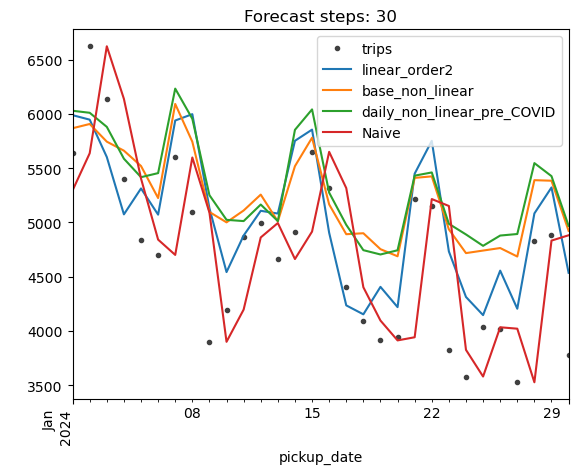

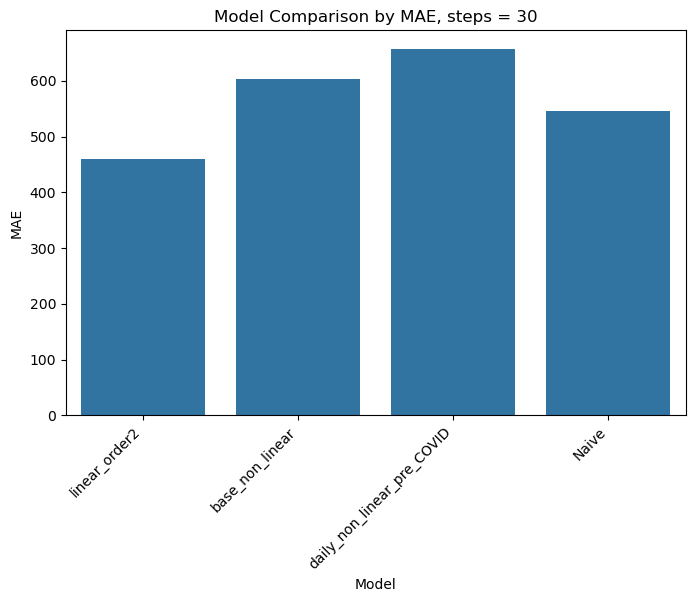

MAE Linear: 460.29 for step = 30, model = linear_order2
MAE Non Linear: 603.34 for step = 30, model = base_non_linear
MAE Non Linear: 779.12 for step = 30, model = daily_non_linear_incl_COVID
Naive MAE: MAE = 545.37



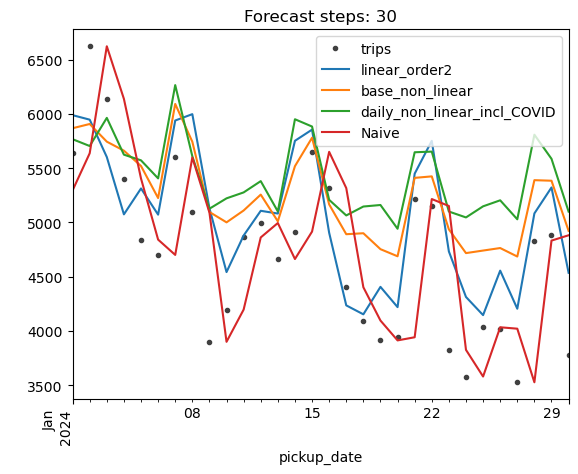

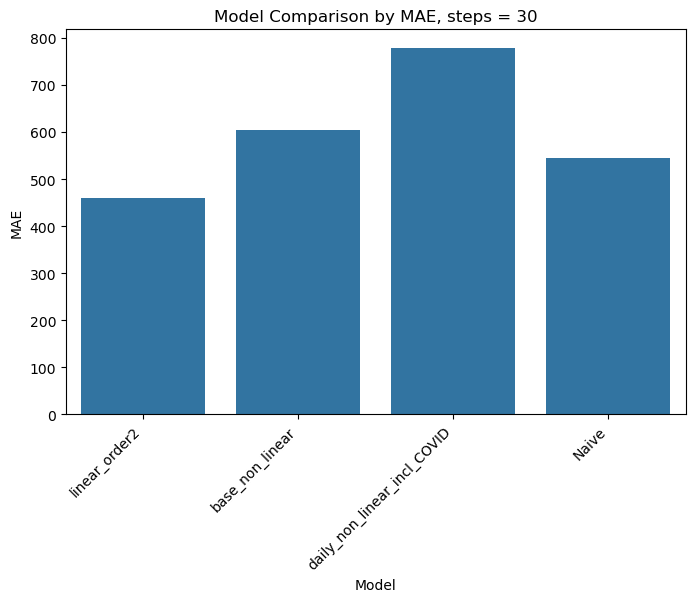

c:\Users\ogilv\miniconda3\envs\datasci\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\ogilv\miniconda3\envs\datasci\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


MAE Linear: 341.65 for step = 30, model = hybrid_order1
MAE Linear: 313.32 for step = 30, model = hybrid_order2
MAE Linear: 355.73 for step = 30, model = daily_hybrid_non_linear_pre_COVID_hybrid_order1
MAE Linear: 338.39 for step = 30, model = daily_hybrid_non_linear_pre_COVID_hybrid_order2
MAE Non Linear: 603.34 for step = 30, model = base_non_linear
Naive MAE: MAE = 545.37



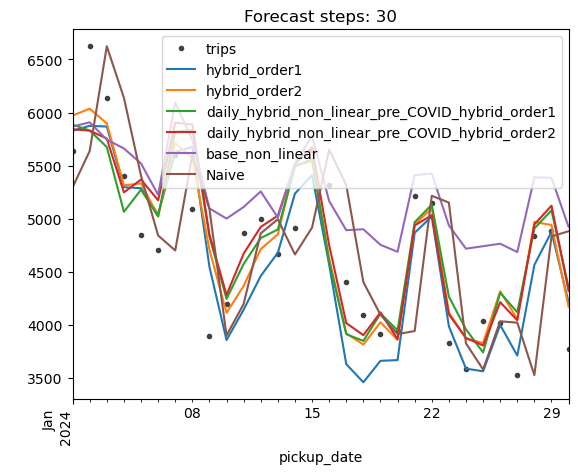

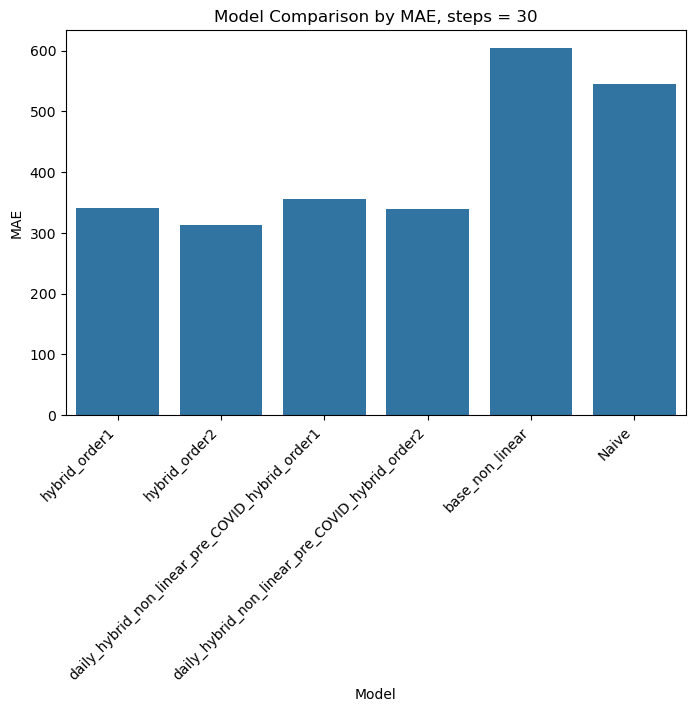

c:\Users\ogilv\miniconda3\envs\datasci\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\ogilv\miniconda3\envs\datasci\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


MAE Linear: 341.65 for step = 30, model = hybrid_order1
MAE Linear: 313.32 for step = 30, model = hybrid_order2
MAE Linear: 468.84 for step = 30, model = daily_hybrid_non_linear_incl_COVID_hybrid_order1
MAE Linear: 481.74 for step = 30, model = daily_hybrid_non_linear_incl_COVID_hybrid_order2
MAE Non Linear: 603.34 for step = 30, model = base_non_linear
Naive MAE: MAE = 545.37



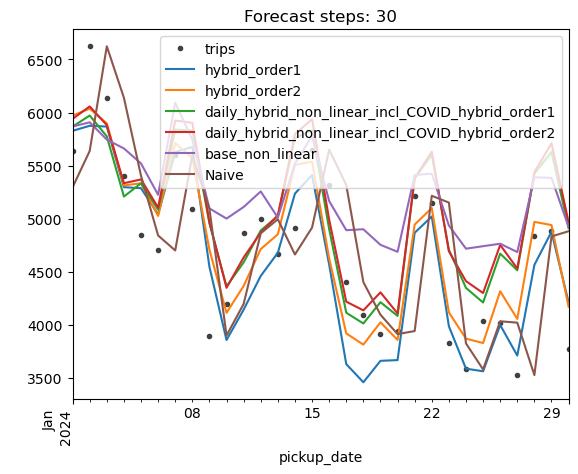

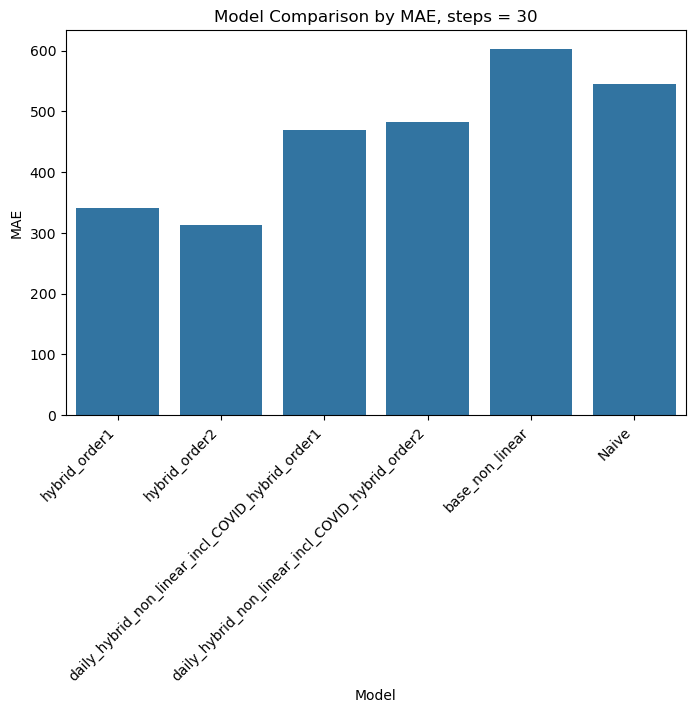

MAE Linear: 46.01 for step = 168, model = linear_order2
MAE Non Linear: 43.92 for step = 168, model = base_non_linear
MAE Non Linear: 44.12 for step = 168, model = hourly_non_linear_pre_COVID
Naive MAE: MAE = 59.89



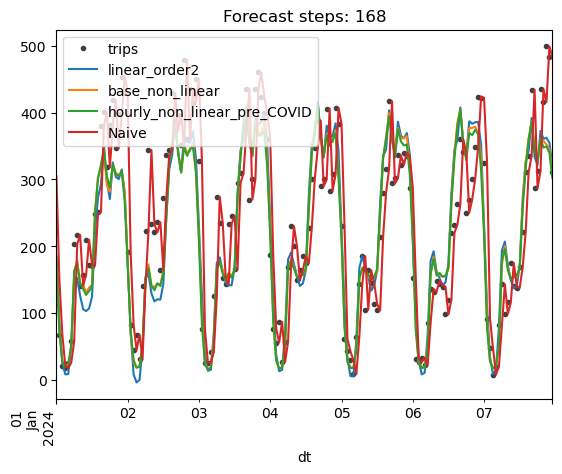

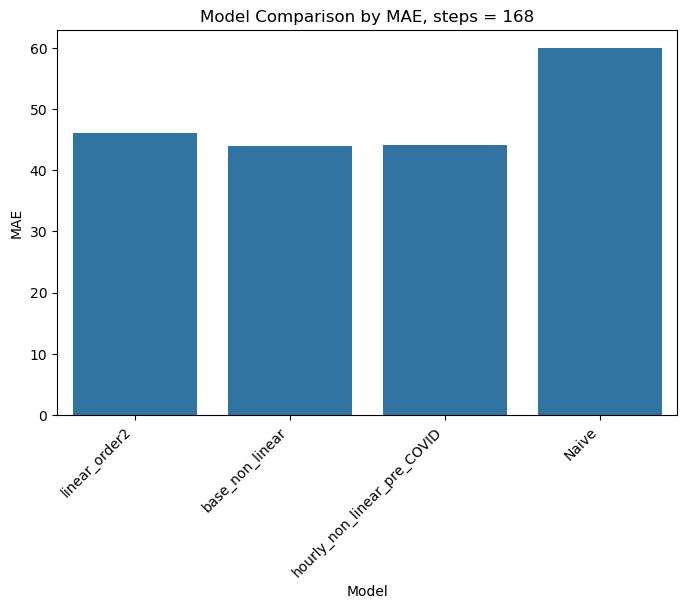

MAE Linear: 46.01 for step = 168, model = linear_order2
MAE Non Linear: 43.92 for step = 168, model = base_non_linear
MAE Non Linear: 45.88 for step = 168, model = hourly_non_linear_incl_COVID
Naive MAE: MAE = 59.89



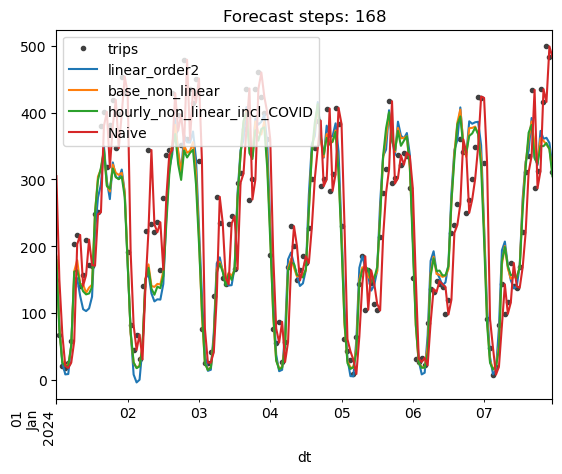

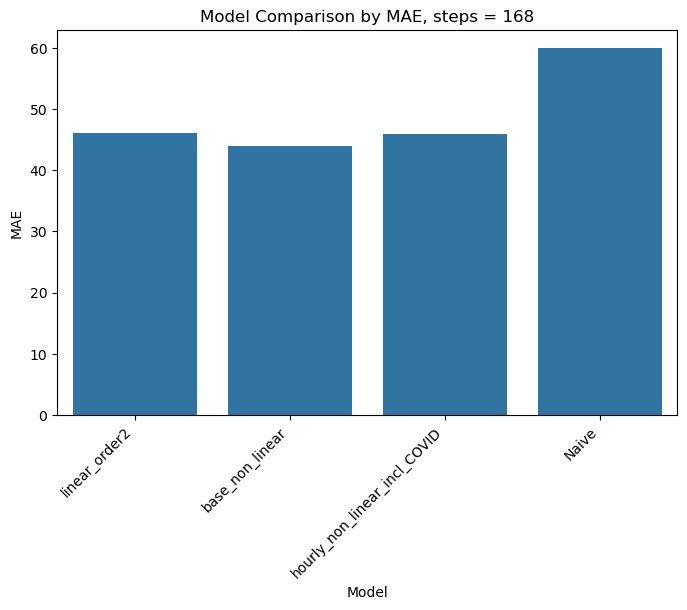

MAE Linear: 46.01 for step = 168, model = linear_order2
MAE Non Linear: 43.92 for step = 168, model = base_non_linear
MAE Non Linear: 46.46 for step = 168, model = hourly_non_linear_post_COVID
Naive MAE: MAE = 59.89



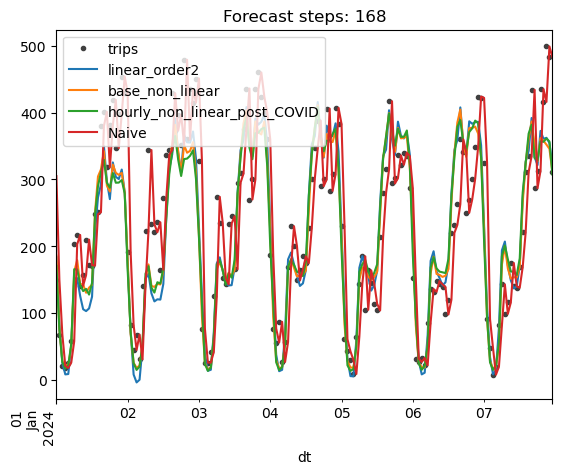

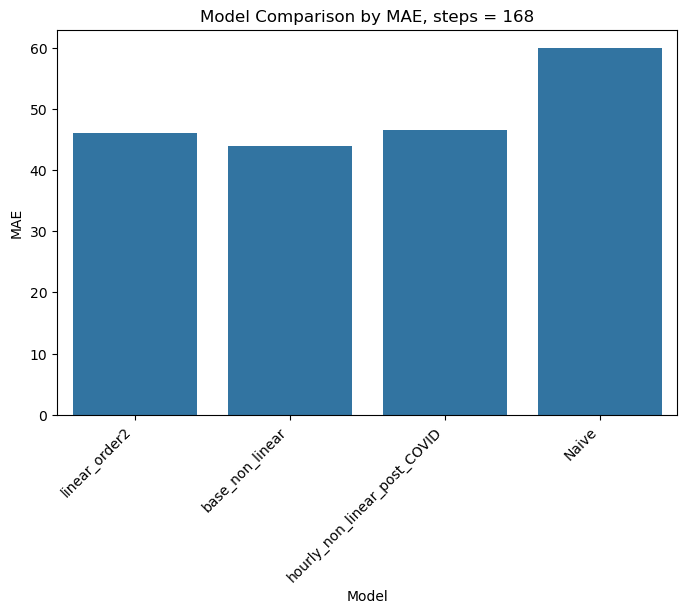

c:\Users\ogilv\miniconda3\envs\datasci\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\ogilv\miniconda3\envs\datasci\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


MAE Linear: 44.30 for step = 168, model = hybrid_order1
MAE Linear: 44.30 for step = 168, model = hybrid_order2
MAE Linear: 44.29 for step = 168, model = hourly_hybrid_non_linear_pre_COVID_hybrid_order1
MAE Linear: 44.20 for step = 168, model = hourly_hybrid_non_linear_pre_COVID_hybrid_order2
MAE Non Linear: 43.92 for step = 168, model = base_non_linear
Naive MAE: MAE = 59.89



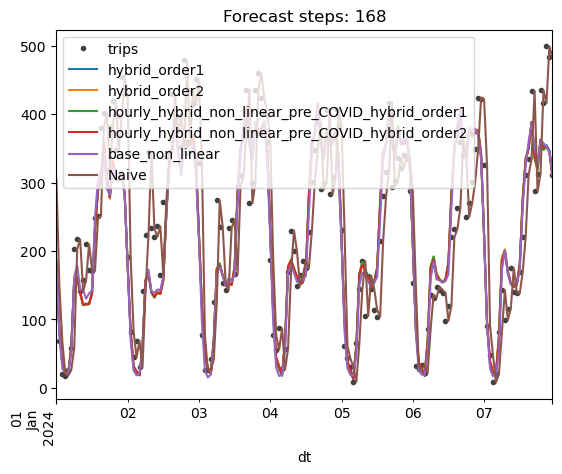

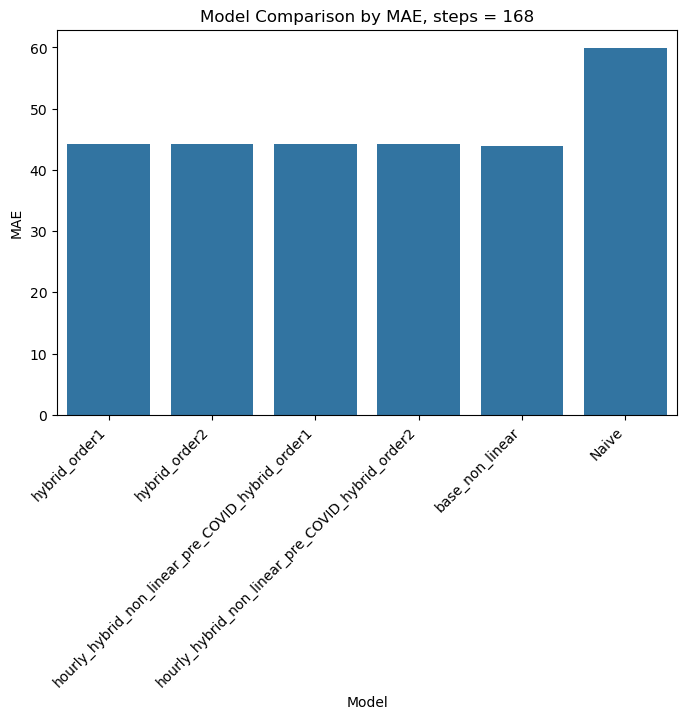

c:\Users\ogilv\miniconda3\envs\datasci\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\ogilv\miniconda3\envs\datasci\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


MAE Linear: 44.30 for step = 168, model = hybrid_order1
MAE Linear: 44.30 for step = 168, model = hybrid_order2
MAE Linear: 43.97 for step = 168, model = hourly_hybrid_non_linear_incl_COVID_hybrid_order1
MAE Linear: 44.32 for step = 168, model = hourly_hybrid_non_linear_incl_COVID_hybrid_order2
MAE Non Linear: 43.92 for step = 168, model = base_non_linear
Naive MAE: MAE = 59.89



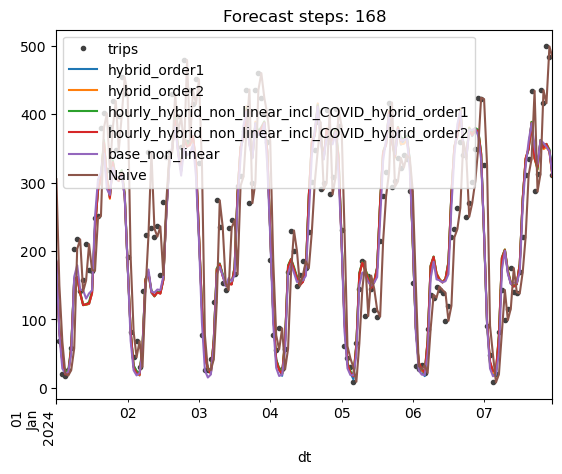

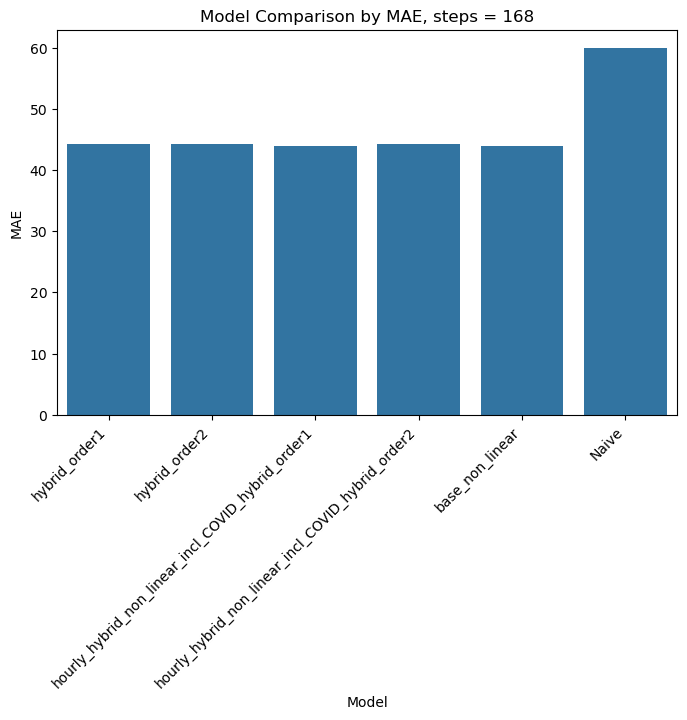

c:\Users\ogilv\miniconda3\envs\datasci\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\ogilv\miniconda3\envs\datasci\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


MAE Linear: 44.30 for step = 168, model = hybrid_order1
MAE Linear: 44.30 for step = 168, model = hybrid_order2
MAE Linear: 44.37 for step = 168, model = hourly_hybrid_non_linear_post_COVID_hybrid_order1
MAE Linear: 43.77 for step = 168, model = hourly_hybrid_non_linear_post_COVID_hybrid_order2
MAE Non Linear: 43.92 for step = 168, model = base_non_linear
Naive MAE: MAE = 59.89



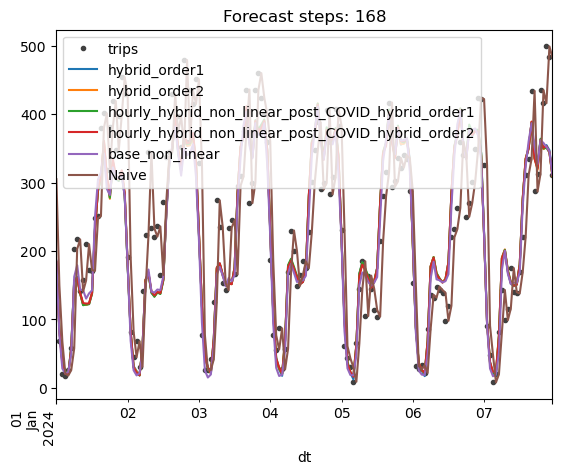

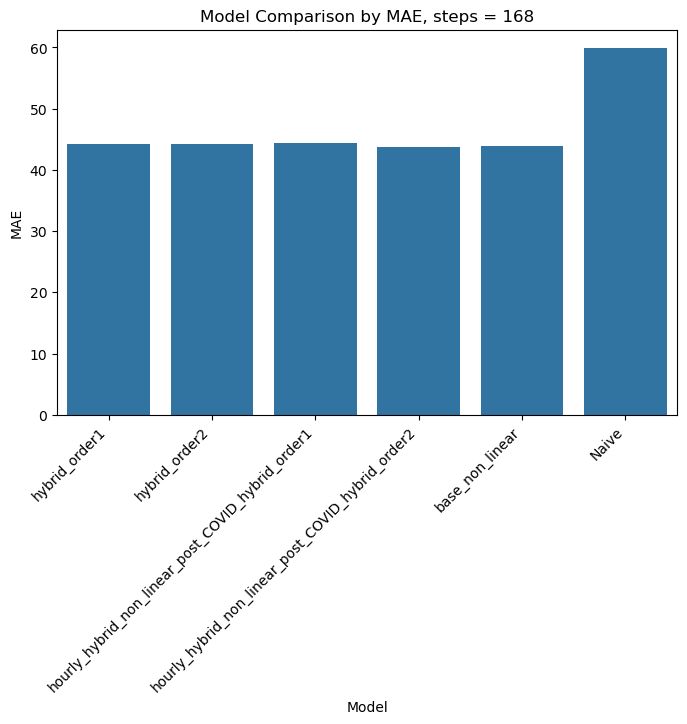

In [29]:
# Run test_hyperparams
test_hyperparams(dict_full, daily_lags, used_hourly_lags, ts_daily_train, ts_daily_test, ts_hourly_train, ts_hourly_test, daily_steps, hourly_steps)

## SHAP values

We now seek to explore the shap values of the models